In [3]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
df=pd.read_csv('city_day.csv')

In [5]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [6]:
df.shape

(29531, 16)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [8]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


_Lets clean the data first_

<Axes: >

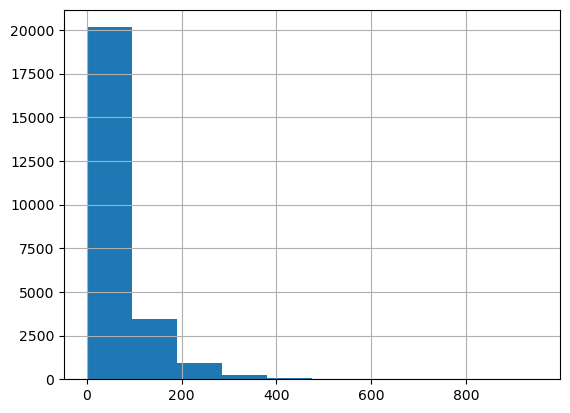

In [9]:
df['PM2.5'].hist()

In [10]:
df['PM2.5'] = df['PM2.5'].fillna(df['PM2.5'].median())

In [11]:
df.columns

Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

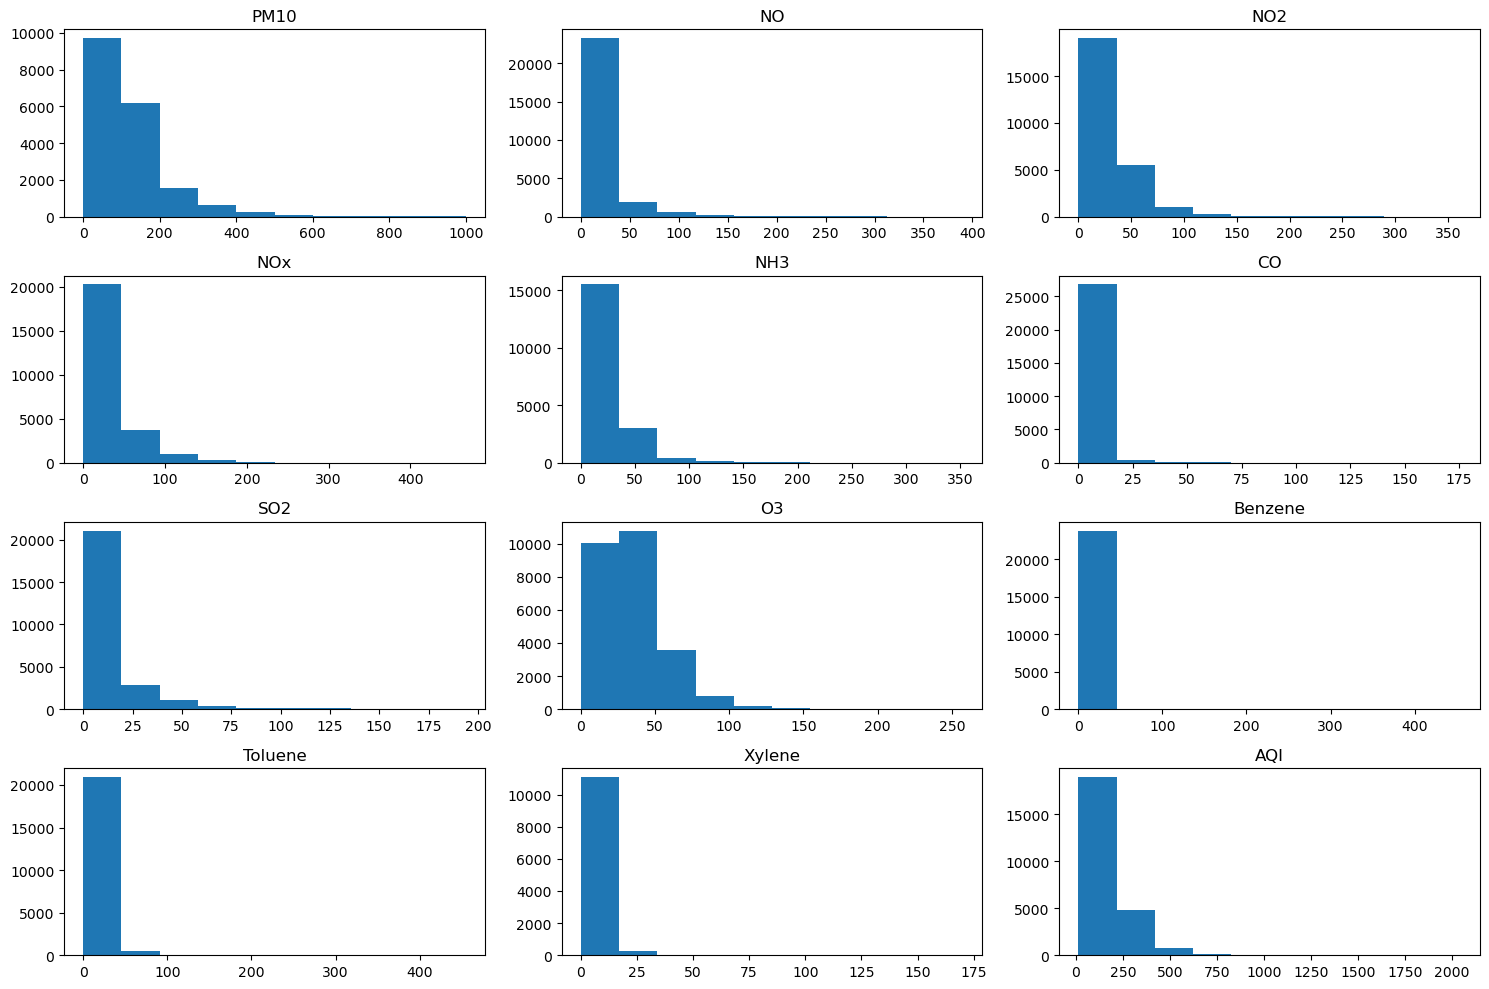

In [12]:
import matplotlib.pyplot as plt

features = ['PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
            'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']

fig, ax = plt.subplots(4, 3, figsize=(15, 10))

for i, col in enumerate(features):
    r = i // 3
    c = i % 3
    ax[r, c].hist(df[col])
    ax[r, c].set_title(col)

plt.tight_layout()
plt.show()

In [13]:
for col in features:
    skew = df[col].skew()
    print(col, skew)

PM10 2.0531890996443782
NO 3.8831662754061536
NO2 2.46455958981977
NOx 2.569914617242555
NH3 4.083993435995747
CO 8.878321521748088
SO2 4.08365955475371
O3 1.3301193221449077
Benzene 21.30421849079058
Toluene 11.666128829133166
Xylene 7.891515253678006
AQI 3.396757197848103


In [14]:
for i in features: 
    df[i].fillna(df[i].median(),inplace=True)

In [15]:
df['AQI_Bucket'].fillna('')

0                    
1                    
2                    
3                    
4                    
             ...     
29526            Good
29527    Satisfactory
29528    Satisfactory
29529    Satisfactory
29530            Good
Name: AQI_Bucket, Length: 29531, dtype: object

In [16]:
city_mean_aqi = df.groupby('City')['AQI'].mean()
df['City_Mean_AQI'] = df['City'].map(city_mean_aqi)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   City           29531 non-null  object 
 1   Date           29531 non-null  object 
 2   PM2.5          29531 non-null  float64
 3   PM10           29531 non-null  float64
 4   NO             29531 non-null  float64
 5   NO2            29531 non-null  float64
 6   NOx            29531 non-null  float64
 7   NH3            29531 non-null  float64
 8   CO             29531 non-null  float64
 9   SO2            29531 non-null  float64
 10  O3             29531 non-null  float64
 11  Benzene        29531 non-null  float64
 12  Toluene        29531 non-null  float64
 13  Xylene         29531 non-null  float64
 14  AQI            29531 non-null  float64
 15  AQI_Bucket     24850 non-null  object 
 16  City_Mean_AQI  29531 non-null  float64
dtypes: float64(14), object(3)
memory usage: 3.8+ MB


In [18]:
df_encoded=df

_LETS PREPROCESS THE DATA_

In [19]:
df_encoded['Date'] = pd.to_datetime(df_encoded['Date'])

df_encoded['year'] = df_encoded['Date'].dt.year
df_encoded['Month'] = df_encoded['Date'].dt.month

df_encoded.drop('Date', axis=1, inplace=True)

In [20]:
def get_season(month):
    if month in [12, 1, 2]:
        return 0   # Winter  → worst AQI typically
    elif month in [3, 4, 5]:
        return 1   # Summer
    elif month in [6, 7, 8, 9]:
        return 2   # Monsoon → best AQI typically
    else:
        return 3   # Post-Monsoon

df['Season'] = df['Month'].apply(get_season)

In [21]:
df.drop('AQI_Bucket',axis=1)

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,City_Mean_AQI,year,Month,Season
0,Ahmedabad,48.57,95.68,0.92,18.22,17.15,15.85,0.92,27.64,133.36,0.00,0.02,0.00,118.0,339.861623,2015,1,0
1,Ahmedabad,48.57,95.68,0.97,15.69,16.46,15.85,0.97,24.55,34.06,3.68,5.50,3.77,118.0,339.861623,2015,1,0
2,Ahmedabad,48.57,95.68,17.40,19.30,29.70,15.85,17.40,29.07,30.70,6.80,16.40,2.25,118.0,339.861623,2015,1,0
3,Ahmedabad,48.57,95.68,1.70,18.48,17.97,15.85,1.70,18.59,36.08,4.43,10.14,1.00,118.0,339.861623,2015,1,0
4,Ahmedabad,48.57,95.68,22.10,21.42,37.76,15.85,22.10,39.33,39.31,7.01,18.89,2.78,118.0,339.861623,2015,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,117.415185,2020,6,2
29527,Visakhapatnam,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,117.415185,2020,6,2
29528,Visakhapatnam,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,117.415185,2020,6,2
29529,Visakhapatnam,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,117.415185,2020,6,2


In [22]:
df_encoded=pd.get_dummies(df_encoded,drop_first=True)

In [23]:
df_encoded

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,...,City_Patna,City_Shillong,City_Talcher,City_Thiruvananthapuram,City_Visakhapatnam,AQI_Bucket_Moderate,AQI_Bucket_Poor,AQI_Bucket_Satisfactory,AQI_Bucket_Severe,AQI_Bucket_Very Poor
0,48.57,95.68,0.92,18.22,17.15,15.85,0.92,27.64,133.36,0.00,...,False,False,False,False,False,False,False,False,False,False
1,48.57,95.68,0.97,15.69,16.46,15.85,0.97,24.55,34.06,3.68,...,False,False,False,False,False,False,False,False,False,False
2,48.57,95.68,17.40,19.30,29.70,15.85,17.40,29.07,30.70,6.80,...,False,False,False,False,False,False,False,False,False,False
3,48.57,95.68,1.70,18.48,17.97,15.85,1.70,18.59,36.08,4.43,...,False,False,False,False,False,False,False,False,False,False
4,48.57,95.68,22.10,21.42,37.76,15.85,22.10,39.33,39.31,7.01,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,...,False,False,False,False,True,False,False,False,False,False
29527,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,...,False,False,False,False,True,False,False,True,False,False
29528,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,...,False,False,False,False,True,False,False,True,False,False
29529,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,...,False,False,False,False,True,False,False,True,False,False


In [24]:
df_encoded=df_encoded.astype(int)

In [25]:
df_encoded

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,...,City_Patna,City_Shillong,City_Talcher,City_Thiruvananthapuram,City_Visakhapatnam,AQI_Bucket_Moderate,AQI_Bucket_Poor,AQI_Bucket_Satisfactory,AQI_Bucket_Severe,AQI_Bucket_Very Poor
0,48,95,0,18,17,15,0,27,133,0,...,0,0,0,0,0,0,0,0,0,0
1,48,95,0,15,16,15,0,24,34,3,...,0,0,0,0,0,0,0,0,0,0
2,48,95,17,19,29,15,17,29,30,6,...,0,0,0,0,0,0,0,0,0,0
3,48,95,1,18,17,15,1,18,36,4,...,0,0,0,0,0,0,0,0,0,0
4,48,95,22,21,37,15,22,39,39,7,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,15,50,7,25,19,12,0,8,23,2,...,0,0,0,0,1,0,0,0,0,0
29527,24,74,3,26,16,11,0,12,30,0,...,0,0,0,0,1,0,0,1,0,0
29528,22,65,3,29,18,10,0,8,30,0,...,0,0,0,0,1,0,0,1,0,0
29529,16,49,4,29,18,10,0,9,28,0,...,0,0,0,0,1,0,0,1,0,0


In [26]:
df_encoded.columns

Index(['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
       'Benzene', 'Toluene', 'Xylene', 'AQI', 'City_Mean_AQI', 'year', 'Month',
       'Season', 'City_Aizawl', 'City_Amaravati', 'City_Amritsar',
       'City_Bengaluru', 'City_Bhopal', 'City_Brajrajnagar', 'City_Chandigarh',
       'City_Chennai', 'City_Coimbatore', 'City_Delhi', 'City_Ernakulam',
       'City_Gurugram', 'City_Guwahati', 'City_Hyderabad', 'City_Jaipur',
       'City_Jorapokhar', 'City_Kochi', 'City_Kolkata', 'City_Lucknow',
       'City_Mumbai', 'City_Patna', 'City_Shillong', 'City_Talcher',
       'City_Thiruvananthapuram', 'City_Visakhapatnam', 'AQI_Bucket_Moderate',
       'AQI_Bucket_Poor', 'AQI_Bucket_Satisfactory', 'AQI_Bucket_Severe',
       'AQI_Bucket_Very Poor'],
      dtype='object')

In [27]:
X=df_encoded.drop('AQI',axis=1)
y=df_encoded['AQI']

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

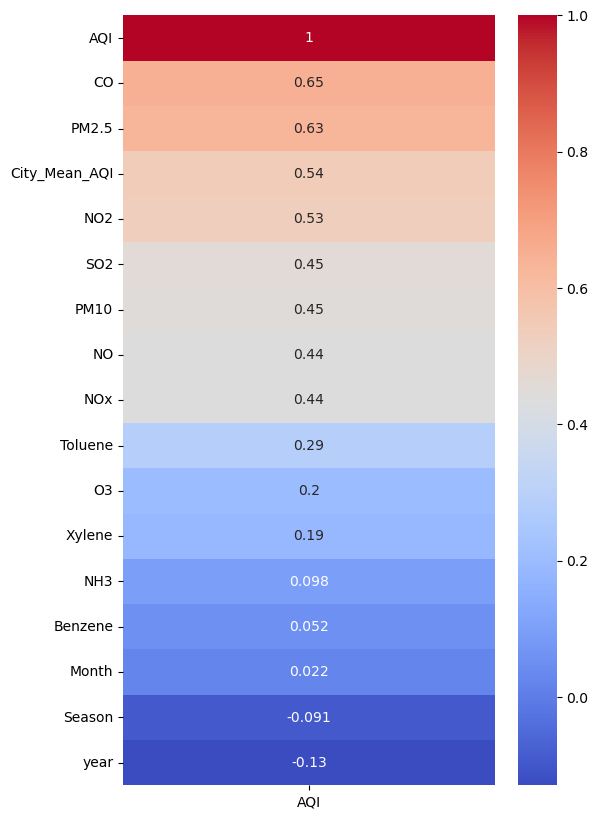

In [29]:
corr = df.corr(numeric_only=True)['AQI'].sort_values(ascending=False)

plt.figure(figsize=(6,10))
sns.heatmap(corr.to_frame(), annot=True, cmap='coolwarm')
plt.show()

In [30]:
final_df= df_encoded[['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
    'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene',
    'Month', 'Season', 'City_Mean_AQI' ,'AQI'  ]]

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
X = final_df.drop('AQI', axis=1)
y = final_df['AQI']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
from sklearn.linear_model import LinearRegression

In [34]:
model=LinearRegression()

In [35]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [36]:
y_pred=model.predict(X_test)

In [37]:
y_test

22593    118
22459    118
24213    137
25301    190
20886    339
        ... 
17614     79
6198      91
9648     106
16507     68
7395     136
Name: AQI, Length: 5907, dtype: int64

In [38]:
from sklearn.metrics import r2_score

In [39]:
r2=r2_score(y_test,y_pred)

In [40]:
r2

0.8132919344085976

In [41]:
n=X_test.shape[0]

In [42]:
p=X_test.shape[1]

In [43]:
adjusted_r2=1-((1-r2)*(n-1)/(n-p-1))

In [44]:
adjusted_r2

0.812816527689217

In [45]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [46]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [47]:
print("XGB R2:", r2_score(y_test, y_pred_xgb))

XGB R2: 0.8825311660766602


In [54]:
from sklearn.ensemble import RandomForestRegressor

mdl = RandomForestRegressor(n_estimators=100, random_state=42)

mdl.fit(X_train, y_train)

y_pred_rf = mdl.predict(X_test)

In [55]:
from sklearn.metrics import r2_score

print("RF R2:", r2_score(y_test, y_pred_rf))

RF R2: 0.8858949534310873


In [56]:
import joblib

joblib.dump(model, 'aqi_model.pkl')

['aqi_model.pkl']

In [57]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [60]:
if hasattr(model, "feature_importances_"):
    import pandas as pd
    importance = pd.Series(model.feature_importances_, index=FEATURE_COLS)
    st.bar_chart(importance.sort_values(ascending=False))